In [218]:
import json, re
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

In [219]:
DATA_DIR = "open-data/data"

In [220]:
def remove_dot_notation(col: str) -> str:
    return re.sub(r"\.(.)", lambda m: m.group(1).upper(), col)

In [221]:
iterations = pd.read_json(f"{DATA_DIR}/iterations.json")

In [222]:
#print(iterations.loc[0, "idMappings"])

In [223]:
ITERATION_ID = 743

squads = pd.read_json(f"{DATA_DIR}/squads/squads_{ITERATION_ID}.json")
players = pd.read_json(f"{DATA_DIR}/players/players_{ITERATION_ID}.json")
countries = pd.read_json(f"{DATA_DIR}/countries.json")
kpi_definitions = pd.read_json(f"{DATA_DIR}/kpi_definitions.json")

## Load Matches

In [224]:
with open(f"{DATA_DIR}/matches/matches_{ITERATION_ID}.json", "r", encoding="utf-8") as f:
    matches_raw = json.load(f)
matches = pd.json_normalize(matches_raw)
matches = matches.rename(columns=remove_dot_notation)

# attach home/away squad names for convenience
matches = (
    matches
    .merge(squads[["id","name"]].rename(columns={"id":"homeSquadId","name":"homeSquadName"}), on="homeSquadId")
    .merge(squads[["id","name"]].rename(columns={"id":"awaySquadId","name":"awaySquadName"}), on="awaySquadId")
)

matches = matches[[
    "iterationId","id","matchDayIndex","matchDayName",
    "homeSquadId","homeSquadName","awaySquadId","awaySquadName",
    "scheduledDate","lastCalculationDate","available"
]].sort_values(["matchDayIndex","scheduledDate","id"]).reset_index(drop=True)

# matches.head(10)

In [225]:
from glob import glob

event_files = sorted(glob(str(f"{DATA_DIR}/events/events_*.json")))
len(event_files), len(matches) # all events are available

match_ids = [int(f.split("_")[-1].replace(".json", "")) for f in event_files]

In [226]:
SAMPLE_MATCH = match_ids[0]
with open(f"{DATA_DIR}/events/events_{SAMPLE_MATCH}.json", "r", encoding="utf-8") as f:
    raw = json.load(f)
df_ev = pd.json_normalize(raw).assign(matchId=SAMPLE_MATCH)
df_ev = df_ev.rename(columns=remove_dot_notation)

df_ev = (
    df_ev
    .merge(squads[["id","name"]].rename(columns={"id":"squadId","name":"squadName"}), on="squadId", how="left")
    .merge(players[["id","commonname"]].rename(columns={"id":"playerId","commonname":"playerName"}), on="playerId", how="left")
)

In [227]:
from tqdm import tqdm

events_all = []

for match_id in tqdm(match_ids, desc="Loading matches"):
    with open(f"{DATA_DIR}/events/events_{match_id}.json", "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.json_normalize(data)
    df = df.rename(columns=remove_dot_notation)
    df["matchId"] = match_id
    events_all.append(df)

all_events_df = pd.concat(events_all, ignore_index=True)

all_events_df = (
    all_events_df
    .merge(squads[["id", "name"]].rename(columns={"id": "squadId", "name": "squadName"}), on="squadId", how="left")
    .merge(players[["id", "commonname"]].rename(columns={"id": "playerId", "commonname": "playerName"}), on="playerId", how="left")
)

Loading matches: 100%|███████████████████████████████████████████████████████████████| 306/306 [00:47<00:00,  6.40it/s]


In [228]:
all_events_df.groupby('matchId').size().reset_index()[0].mean()

3069.281045751634

In [229]:
all_events_df[all_events_df['pxT'].notna()][['pxT']]

,pxT


In [230]:
all_events_df.columns

Index(['index', 'id', 'squadId', 'pressure', 'actionType', 'end', 'action',
       'phase', 'duel', 'shot', 'currentAttackingSquadId', 'bodyPart',
       'bodyPartExtended', 'previousPassHeight', 'duration', 'opponents',
       'distanceToGoal', 'result', 'periodId', 'pressingPlayerId',
       'fouledPlayerId', 'distanceToOpponent', 'setPiece', 'sequenceIndex',
       'inferredSetPiece', 'gameTimeGameTime', 'gameTimeGameTimeInSec',
       'playerId', 'playerPosition', 'playerPositionSide', 'startCoordinatesX',
       'startCoordinatesY', 'startAdjCoordinatesX', 'startAdjCoordinatesY',
       'startPackingZone', 'startPitchPosition', 'startLane', 'passDistance',
       'passAngle', 'passReceiver', 'pxTTeam', 'pxTOpponent', 'formationTeam',
       'formationOpponent', 'player', 'start', 'pass', 'pxT', 'formation',
       'endCoordinatesX', 'endCoordinatesY', 'endAdjCoordinatesX',
       'endAdjCoordinatesY', 'endPackingZone', 'endPitchPosition', 'endLane',
       'passReceiverPlayerId', 

In [231]:
all_events_df['playerId'] = all_events_df['playerId'].astype("Int64")
all_events_df['squadId'] = all_events_df['squadId'].astype("Int64")


all_events_df['pressingPlayerId'] = all_events_df['pressingPlayerId'].astype("Int64")
all_events_df['fouledPlayerId'] = all_events_df['fouledPlayerId'].astype("Int64")

all_events_df['duelPlayerId'] = all_events_df['duelPlayerId'].astype("Int64")
all_events_df['setPieceId'] = all_events_df['setPieceId'].astype("Int64")

In [232]:
simplified_cols = [
    "matchId", "periodId", "sequenceIndex",
    "squadId", "squadName",
    "playerId", "playerName",
    "playerPosition", "playerPositionSide",
    "actionType", "action", "result",
    "startCoordinatesX", "startCoordinatesY",
    "endCoordinatesX", "endCoordinatesY",
    "gameTimeGameTimeInSec"
]
simplified_all_events_df = all_events_df[[c for c in simplified_cols if c in all_events_df.columns]]

## Get Preferred Positions based on Event Count

positions for players was inferred based on the position which had the most events

In [233]:
df_pos = all_events_df.dropna(subset=["playerId", "playerPosition"])

position_counts = (
    df_pos.groupby(["playerId", "playerName", "playerPosition", "playerPositionSide"])
    .size()
    .reset_index(name="eventCount")
)

preferred_positions = (
    position_counts
    .sort_values(["playerId", "eventCount"], ascending=[True, False])
    .drop_duplicates(subset="playerId")
    .reset_index(drop=True)
)
preferred_positions.columns = ['playerId','playerName','preferredPosition','PositionSide','eventCount']

In [234]:
preferred_positions[preferred_positions['playerId']==409]

,playerId,playerName,preferredPosition,PositionSide,eventCount
16,409,Raphaël Guerreiro,LEFT_WINGBACK_DEFENDER,LEFT,1317


In [235]:
players = (
    players
    .merge(
        preferred_positions[["playerId", "preferredPosition", "PositionSide"]],
        left_on="id",right_on='playerId',
        how="left"
    )
)

## Lineups

There were discrepancies between the preffered positions of the lineup and the the amount of the event data, based on subjective knowledge i went with the event data

In [236]:
iteration_id = 743

lineup_files = sorted(glob(f"{DATA_DIR}/lineups/lineups_*.json"))

lineups_all = []
for fpath in lineup_files:
    match_id = int(fpath.split("_")[-1].replace(".json", ""))
    with open(f"{DATA_DIR}/lineups/lineups_{match_id}.json", "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.json_normalize(data)
    df["matchId"] = match_id
    lineups_all.append(df)

lineups_df = pd.concat(lineups_all, ignore_index=True)
lineups_df.columns = [c.replace(".", "_") for c in lineups_df.columns]

import pandas as pd
from collections import Counter

def extract_positions_from_list(lst):
    if not isinstance(lst, list):
        return Counter()
    positions = [d.get("position") for d in lst if isinstance(d, dict) and "playerId" in d]
    player_ids = [d.get("playerId") for d in lst if isinstance(d, dict)]
    return list(zip(player_ids, positions))

# collect (playerId, position) pairs from both home and away lists
pairs = []
for _, row in lineups_df.iterrows():
    pairs.extend(extract_positions_from_list(row.get("squadHome_startingPositions")))
    pairs.extend(extract_positions_from_list(row.get("squadAway_startingPositions")))
pos_df = pd.DataFrame(pairs, columns=["playerId", "position"]).dropna()

pos_counts = (
    pos_df.groupby(["playerId", "position"])
    .size()
    .reset_index(name="count")
    .sort_values(["playerId", "count"], ascending=[True, False])
#    .drop_duplicates(subset='playerId',keep='first')
)
pos_counts.rename(columns={'position':'preferredposition_from_lineups'},inplace=True)

players = (
    players
    .merge(
        pos_counts[["playerId", 'count',"preferredposition_from_lineups"]],
        left_on="id",right_on='playerId',
        how="left"
    )
)

In [255]:
players[players['firstname']=='Jeremie']

,id,firstname,lastname,commonname,birthdate,birthplace,leg,countryIds,gender,currentSquadId,idMappings,playerId_x,preferredPosition,PositionSide,playerId_y,count,preferredposition_from_lineups
540,27161,Jeremie,Frimpong,Jeremie Frimpong,2000-12-10,Amsterdam,RIGHT,"[498, 384]",MALE,297.0,"[{'heim_spiel': ['513351']}, {'skill_corner': ...",27161,RIGHT_WINGBACK_DEFENDER,RIGHT,27161.0,26.0,RIGHT_WINGBACK_DEFENDER
541,27161,Jeremie,Frimpong,Jeremie Frimpong,2000-12-10,Amsterdam,RIGHT,"[498, 384]",MALE,297.0,"[{'heim_spiel': ['513351']}, {'skill_corner': ...",27161,RIGHT_WINGBACK_DEFENDER,RIGHT,27161.0,1.0,ATTACKING_MIDFIELD


In [20]:
#players[players['preferredposition_from_lineups']!=players['preferredPosition_x']]

## Event KPIs

In [21]:
kpi_defs = pd.read_json(f"{DATA_DIR}/kpi_definitions.json")

kpi_frames = []
for mid in tqdm(match_ids, desc="Loading event KPIs"):
    with open(f"{DATA_DIR}/events_kpis/events_kpis_{mid}.json", "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.json_normalize(data)
    df["matchId"] = mid
    kpi_frames.append(df)

event_kpis = pd.concat(kpi_frames, ignore_index=True)

event_kpis = event_kpis.merge(
    kpi_defs[["id", "name"]].rename(columns={"id": "kpiId", "name": "kpiName"}),
    on="kpiId",
    how="left"
)

Loading event KPIs: 100%|████████████████████████████████████████████████████████████| 306/306 [01:15<00:00,  4.08it/s]


In [22]:
event_kpis = event_kpis.merge(kpi_definitions[['id','name']],left_on='kpiId',right_on='id',how='left')

In [23]:
event_kpis.rename(columns={'name':'kpi_name','value':'kpi_value'},inplace=True)

In [24]:
event_kpis[event_kpis['id']==28].groupby('eventId').count()

,position,playerId,kpiId,kpi_value,matchId,kpiName,id,kpi_name
eventId,,,,,,,,
4607671608,1,1,1,1,1,1,1,1
4607671797,1,1,1,1,1,1,1,1
4607672209,1,1,1,1,1,1,1,1
4607673074,1,1,1,1,1,1,1,1
4607673414,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...
4885769249,1,1,1,1,1,1,1,1
4885769681,1,1,1,1,1,1,1,1
4885769836,1,1,1,1,1,1,1,1


In [25]:
#all_events_df[all_events_df['action']=='GOAL']

In [26]:
#event_kpis[event_kpis['eventId']==4858179240]

In [27]:
len(event_kpis)

9071592

In [28]:
#kpi_definitions[kpi_definitions['name'].str.contains('XG')]

The reality of the data model

 - Each event represents a single, physical football action.

 - But multiple players can be “involved” or “affected” by that same event:

 - The player who performed it (goalkeeper making a pass).

 - The opposing players who were bypassed, pressed, or defending.

 - Even teammates who were receiving or involved in packing metrics.

In [29]:
all_events_df.rename(columns={'id':'eventId'},inplace=True)

In [30]:
all_events_df_x_kpis = (
    all_events_df
    .merge(event_kpis[['matchId','eventId','playerId','kpi_name','kpi_value']], on=["matchId", "eventId", "playerId"], how="left")
)

In [31]:
len(all_events_df_x_kpis)

5738484

# Phase 1: Actor Based - What the Fullback Did?

i use only the events where the full-back is the acting player. Merge event + KPI by (matchId, eventId, playerId) and measure direct contributions

Purpose: quantifies the player’s offensive involvements.

In [32]:
print("action:",all_events_df_x_kpis['action'].unique())
print("actiontype:",all_events_df_x_kpis['actionType'].unique())
print("kpi_name:",all_events_df_x_kpis['kpi_name'].unique())
print("result:",all_events_df_x_kpis['result'].unique())

action: ['KICKOFF_WHISTLE' 'VIDEO_NOT_AVAILABLE' 'AVAILABILITY_IN_THE_BACK'
 'DRIBBLE' 'DIAGONAL_PASS' 'HEADER' 'HOLD_UP_PLAY' 'CLEARANCE'
 'BALL_OUT_OF_SIDE_LINE' 'THROW_IN' 'AVAILABILITY_BTL' 'LOW_PASS'
 'CHIPPED_PASS' 'LOOSE_BALL_REGAIN' 'AVAILABILITY_OUT_WIDE' 'DUEL' 'FOUL'
 'FREE_KICK' 'BLOCK' 'BALL_OUT_OF_GOAL_LINE' 'GOAL_KICK'
 'SHORT_AERIAL_PASS' 'AVAILABILITY_FDR' 'ONE_VS_ONE_AGAINST_GK' 'GOAL'
 'INTERCEPTION' 'OFFSIDE' 'LONG_RANGE_SHOT' 'HIGH_CROSS' 'CATCH'
 'LOW_CROSS' 'BALL_OUT_OF_UNKNOWN' 'MID_RANGE_SHOT' 'DIRECT_FREE_KICK'
 'CORNER' 'CLOSE_RANGE_SHOT' 'SAVE' 'AVAILABILITY_IN_THE_BOX'
 'FINAL_WHISTLE' 'REFERY_INTERCEPTION' 'OWN_GOAL' 'PENALTY_KICK'
 'OPEN_GOAL_SHOT' 'RED_CARD']
actiontype: ['KICK_OFF' 'NO_VIDEO' 'RECEPTION' 'DRIBBLE' 'PASS' 'LOOSE_BALL_REGAIN'
 'CLEARANCE' 'OUT' 'THROW_IN' 'GROUND_DUEL' 'FOUL' 'FREE_KICK' 'BLOCK'
 'GOAL_KICK' 'SHOT' 'GOAL' 'INTERCEPTION' 'OFFSIDE' 'GK_CATCH' 'CORNER'
 'GK_SAVE' 'FINAL_WHISTLE' 'REFEREE_INTERCEPTION' 'OWN_GOAL' 'RED_CARD']


In [33]:
players.rename(columns={'playerId_x':'playerId'},inplace=True)

In [34]:
fullbacks_events_df_x_kpis = (
    all_events_df_x_kpis
    .merge(players[["playerId", "preferredPosition"]], on="playerId", how="left")
    .query("preferredPosition in ['RIGHT_WINGBACK_DEFENDER', 'LEFT_WINGBACK_DEFENDER']")
)

In [35]:
fullbacks_events_df_x_kpis.to_pickle('phase1_fb.pkl')

## Metrics in Phase 1:

### General On-Ball Metrics

#### Volume & Involvement

 - Touches / Events per 90 → total number of events / minutes

 - Passes Attempted / Completed % → using actionType == 'Pass', result == 'Success'

 - Dribbles Attempted / Success % → actionType == 'Dribble', result == 'Success'

 - Duels Won % → actionType == 'Duel', result == 'Success'

 - Progressive Actions per 90 → sums of PXT_PASS, PXT_DRIBBLE

#### Ball Progression & Threat

 - Avg pxT per Action → mean of all PXT_* KPIs (passing + dribbling + shots)

 - Total pxT per 90 → sum of positive pxT values per 90 min

 - Bypassed Opponents per Action → avg Bypassed Opponents KPI

#### Retention & Safety

 - ball losses and critical ball losses

 - Fouls Committed

 - Avg Pass Length / Angle → from passDistance, passAngle
 - avg forwardness
 - execution vs intended

In [36]:
event_level = fullbacks_events_df_x_kpis.drop_duplicates(subset=["matchId","eventId","playerId"])

In [37]:
mins_per_match = (
    event_level.groupby(["playerId", "playerName", "matchId"], as_index=False)["gameTimeGameTimeInSec"]
    .max()
    .assign(mins_in_match=lambda d: d["gameTimeGameTimeInSec"].div(60).clip(lower=0, upper=100))
    [["playerId", "playerName", "matchId", "mins_in_match"]]
)
player_minutes = (
    mins_per_match.groupby(["playerId", "playerName"], as_index=False)["mins_in_match"].sum()
    .rename(columns={"mins_in_match": "minutes_played"})
)

actor_events = (
    event_level.groupby(["playerId", "playerName"])
    .size()
    .reset_index(name="actor_events")
)

events_per90_metrics = (
    actor_events
    .merge(player_minutes, on=["playerId", "playerName"], how="left")
    .assign(
        minutes_played=lambda d: d["minutes_played"].fillna(0),
        events_per_90=lambda d: np.where(d["minutes_played"] > 0, d["actor_events"] * 90 / d["minutes_played"], np.nan)
    )
    .sort_values("events_per_90", ascending=False)
)
events_per90_metrics

,playerId,playerName,actor_events,minutes_played,events_per_90
0,98,Joshua Kimmich,6146,2703.834900,204.576100
60,30670,Ian Maatsen,3011,1493.089018,181.496211
51,13823,David Raum,5644,3100.000000,163.858065
32,5616,Alejandro Grimaldo,5927,3300.000000,161.645455
62,32432,Alphonso Davies,4910,2756.297683,160.323757
...,...,...,...,...,...
10,1046,Patrick Herrmann,144,800.000000,16.200000
87,104788,Elias Baum,63,400.000000,14.175000
90,109588,Leon Opitz,40,300.000000,12.000000
6,944,Timothy Chandler,75,600.000000,11.250000


In [71]:
#main metrics

goals = (
    fullbacks_events_df_x_kpis.query("kpi_name == 'GOALS'")
    .groupby(['playerId','playerName'], as_index=False)['kpi_value']
    .sum()
    .rename(columns={'kpi_value':'goals_total'})
)

assists = (
    fullbacks_events_df_x_kpis.query("kpi_name == 'ASSISTS'")
    .groupby(['playerId','playerName'], as_index=False)['kpi_value']
    .sum()
    .rename(columns={'kpi_value':'assists_total'})
)

xg = (
    fullbacks_events_df_x_kpis.query("kpi_name == 'SHOT_XG'")
    .groupby(['playerId','playerName'], as_index=False)['kpi_value']
    .sum()
    .rename(columns={'kpi_value':'xg_total'})
)

postxg = (
    fullbacks_events_df_x_kpis.query("kpi_name == 'POSTSHOT_XG'")
    .groupby(['playerId','playerName'], as_index=False)['kpi_value']
    .sum()
    .rename(columns={'kpi_value':'postxg_total'})
)

xthreat = (
    fullbacks_events_df_x_kpis.query("kpi_name in ['PXT_PASS','PXT_DRIBBLE','PXT_SHOT']")
    .groupby(['playerId','playerName'], as_index=False)['kpi_value']
    .sum()
    .rename(columns={'kpi_value':'xthreat_total'})
)

main_metrics = goals.merge(assists, on=['playerId','playerName'], how='outer') \
    .merge(xg, on=['playerId','playerName'], how='outer') \
    .merge(postxg, on=['playerId','playerName'], how='outer') \
    .merge(xthreat, on=['playerId','playerName'], how='outer') \
    .fillna(0)

main_metrics = (
    main_metrics.merge(player_minutes, on=['playerId','playerName'], how='left')
    .assign(
        minutes_played=lambda d: d['minutes_played'].fillna(0),
        goals_per_90=lambda d: np.where(d['minutes_played']>0, d['goals_total']*90/d['minutes_played'], np.nan),
        assists_per_90=lambda d: np.where(d['minutes_played']>0, d['assists_total']*90/d['minutes_played'], np.nan),
        xg_per_90=lambda d: np.where(d['minutes_played']>0, d['xg_total']*90/d['minutes_played'], np.nan),
        postxg_per_90=lambda d: np.where(d['minutes_played']>0, d['postxg_total']*90/d['minutes_played'], np.nan),
        xthreat_per_90=lambda d: np.where(d['minutes_played']>0, d['xthreat_total']*90/d['minutes_played'], np.nan)
    )
    .drop(columns=['minutes_played'])
)

main_metrics['finishing_ratio'] = main_metrics['goals_total']/main_metrics['xg_total']

In [72]:
main_metrics.sort_values('finishing_ratio',ascending=False)

,playerId,playerName,goals_total,assists_total,xg_total,postxg_total,xthreat_total,goals_per_90,assists_per_90,xg_per_90,postxg_per_90,xthreat_per_90,finishing_ratio
75,52945,Niels Nkounkou,3.0,3.0,0.75115,1.19175,3.426304,0.096750,0.096750,0.024224,0.038434,0.110498,3.993876
15,1232,Philipp Max,1.0,4.0,0.26144,0.60670,1.834844,0.041039,0.164157,0.010729,0.024898,0.075300,3.824969
34,6183,Rogério,1.0,0.0,0.29480,0.49897,1.208560,0.072352,0.000000,0.021329,0.036102,0.087442,3.392130
54,21558,Robin Gosens,6.0,3.0,2.40785,4.05678,3.675182,0.183200,0.091600,0.073520,0.123867,0.112216,2.491850
59,29720,Julian Ryerson,4.0,1.0,1.63844,1.39792,1.131627,0.171429,0.042857,0.070219,0.059911,0.048498,2.441347
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,104788,Elias Baum,0.0,0.0,0.00000,0.00000,-0.016755,0.000000,0.000000,0.000000,0.000000,-0.003770,NaN
88,105928,Nnamdi Collins,0.0,0.0,0.00000,0.00000,0.111060,0.000000,0.000000,0.000000,0.000000,0.049977,NaN
89,106573,Lukas Ullrich,0.0,0.0,0.00000,0.00000,-0.130010,0.000000,0.000000,0.000000,0.000000,-0.039003,NaN
90,109588,Leon Opitz,0.0,0.0,0.00000,0.00000,-0.033565,0.000000,0.000000,0.000000,0.000000,-0.010069,NaN


In [38]:
#kpi_definitions.loc[kpi_definitions['name']=='OFFENSIVE_TOUCHES','details'].iloc[0]

offensive touches are for on-ball involvement in possession, not just event count, since it filters out defensive or chaotic actions.

In [39]:
# offensive touches per 90

off_touches_metrics = (
    fullbacks_events_df_x_kpis.query("kpi_name == 'OFFENSIVE_TOUCHES'")
    .groupby(["playerId", "playerName"], as_index=False)["kpi_value"]
    .sum()
    .rename(columns={"kpi_value": "offensive_touches"})
)

off_touches_metrics = (
    off_touches_metrics
    .merge(player_minutes, on=["playerId", "playerName"], how="left")
    .assign(
        minutes_played=lambda d: d["minutes_played"].fillna(0),
        offensive_touches_per_90=lambda d: np.where(d["minutes_played"] > 0, d["offensive_touches"] * 90 / d["minutes_played"], np.nan)
    )
    .sort_values("offensive_touches_per_90", ascending=False)
)
off_touches_metrics

,playerId,playerName,offensive_touches,minutes_played,offensive_touches_per_90
0,98,Joshua Kimmich,1859.0,2703.834900,61.878778
60,30670,Ian Maatsen,871.0,1493.089018,52.501893
32,5616,Alejandro Grimaldo,1739.0,3300.000000,47.427273
62,32432,Alphonso Davies,1402.0,2756.297683,45.778800
51,13823,David Raum,1543.0,3100.000000,44.796774
...,...,...,...,...,...
10,1046,Patrick Herrmann,39.0,800.000000,4.387500
87,104788,Elias Baum,17.0,400.000000,3.825000
6,944,Timothy Chandler,25.0,600.000000,3.750000
86,104512,Fabio Torsiello,31.0,947.956200,2.943174


In [40]:
pass_df = event_level.query("actionType == 'PASS'")

pass_metrics = (
    pass_df.groupby(["playerId", "playerName"], as_index=False)
    .agg(
        total_passes=("actionType", "count"),
        successful_passes=("result", lambda x: (x == "SUCCESS").sum()),
        failed_passes=("result", lambda x: (x == "FAIL").sum())
    )
    .assign(
        pass_accuracy=lambda d: d["successful_passes"] / (d["successful_passes"] + d["failed_passes"])
    )
    .sort_values("pass_accuracy", ascending=False)
)
pass_metrics

,playerId,playerName,total_passes,successful_passes,failed_passes,pass_accuracy
91,112388,Matteo Pérez Vinlöf,11,9,1,0.900000
17,1275,Frank Ronstadt,42,34,4,0.894737
37,7594,Konrad Laimer,1382,1168,143,0.890923
40,8358,Noussair Mazraoui,900,758,94,0.889671
0,98,Joshua Kimmich,1997,1697,217,0.886625
...,...,...,...,...,...,...
87,104788,Elias Baum,19,10,7,0.588235
86,104512,Fabio Torsiello,32,14,16,0.466667
30,5097,Oliver Burke,8,3,4,0.428571
89,106573,Lukas Ullrich,21,7,10,0.411765


In [41]:
# dribbles attempted, success rate

dribble_df = event_level.query("actionType == 'DRIBBLE'")

dribble_metrics = (
    dribble_df.groupby(["playerId", "playerName"], as_index=False)
    .agg(
        dribbles_attempted=("actionType", "count"),
        dribbles_successful=("result", lambda x: (x == "SUCCESS").sum()),
        dribbles_failed=("result", lambda x: (x == "FAIL").sum())
    )
    .assign(
        dribble_success_rate=lambda d: d["dribbles_successful"] / (d["dribbles_attempted"])
    )
    .sort_values("dribble_success_rate", ascending=False)
)

dribble_metrics

,playerId,playerName,dribbles_attempted,dribbles_successful,dribbles_failed,dribble_success_rate
84,103396,El Chadaille Bitshiabu,41,41,0,1.000000
30,5097,Oliver Burke,6,6,0,1.000000
5,787,Thorgan Hazard,5,5,0,1.000000
87,104788,Elias Baum,11,11,0,1.000000
21,1457,Marnon Busch,220,218,2,0.990909
...,...,...,...,...,...,...
71,49451,Sacha Boey,39,33,5,0.846154
22,1477,Danilo Soares,77,65,8,0.844156
52,15811,Ritsu Doan,559,471,64,0.842576
90,109588,Leon Opitz,10,8,2,0.800000


In [42]:
# progressive actions per 90 (pxt_pass + pxt_dribble)

progressive_metrics = (
    fullbacks_events_df_x_kpis
    .query("kpi_name in ['PXT_PASS','PXT_DRIBBLE']")
    .groupby(["playerId","playerName"],as_index=False)["kpi_value"]
    .sum()
    .rename(columns={"kpi_value":"pxT_from_passes_and_dribbles"})
)

progressive_metrics = (
    progressive_metrics
    .merge(player_minutes,on=["playerId","playerName"],how="left")
    .assign(
        minutes_played=lambda d: d["minutes_played"].fillna(0),
        pxT_from_passes_and_dribbles_per_90=lambda d: np.where(d["minutes_played"]>0, d["pxT_from_passes_and_dribbles"]*90/d["minutes_played"], np.nan)
    )
    .sort_values("pxT_from_passes_and_dribbles_per_90",ascending=False)
)
progressive_metrics

,playerId,playerName,pxT_from_passes_and_dribbles,minutes_played,pxT_from_passes_and_dribbles_per_90
18,1297,Maximilian Mittelstädt,5.941660,3047.659117,0.175462
51,13823,David Raum,5.003967,3100.000000,0.145276
55,21832,Franck Honorat,4.949952,3200.000000,0.139217
92,113599,Arthur,0.605978,400.000000,0.136345
0,98,Joshua Kimmich,3.998207,2703.834900,0.133085
...,...,...,...,...,...
30,5097,Oliver Burke,-0.022905,100.000000,-0.020615
63,33056,Roberto Massimo,-0.139699,500.000000,-0.025146
35,6455,Mateu Morey,-0.087187,244.105735,-0.032145
71,49451,Sacha Boey,-0.082421,200.000000,-0.037089


only added pxt_pass and pxt_dribble but those go slightly beyond “progression”

In [43]:
avg_pxt_metrics = (
    fullbacks_events_df_x_kpis
    .query("kpi_name in ['PXT_PASS','PXT_DRIBBLE','PXT_SHOT','PXT_ATTACK','PXT_SETPIECE']")
    .groupby(['playerId','playerName'],as_index=False)['kpi_value']
    .mean()
    .rename(columns={'kpi_value':'avg_pxt_per_action'})
    .sort_values('avg_pxt_per_action',ascending=False)
)
avg_pxt_metrics

,playerId,playerName,avg_pxt_per_action
85,103990,Frans Krätzig,0.011941
33,5835,Nathan Tella,0.004557
11,1077,Felix Passlack,0.002925
57,27161,Jeremie Frimpong,0.002875
44,9915,Maximilian Wittek,0.002744
...,...,...,...
86,104512,Fabio Torsiello,-0.001726
71,49451,Sacha Boey,-0.001817
63,33056,Roberto Massimo,-0.002120
89,106573,Lukas Ullrich,-0.002816


In [44]:
total_pxt_metrics = (
    fullbacks_events_df_x_kpis
    .query("kpi_name in ['PXT_PASS','PXT_DRIBBLE','PXT_SHOT','PXT_ATTACK','PXT_SETPIECE','PACKING_XG']")
    .groupby(['playerId','playerName'],as_index=False)['kpi_value']
    .sum()
    .rename(columns={'kpi_value':'total_positive_pxt'})
)

total_pxt_metrics = (
    total_pxt_metrics
    .merge(player_minutes,on=['playerId','playerName'],how='left')
    .assign(
        minutes_played=lambda d: d['minutes_played'].fillna(0),
        total_positive_pxt_per_90=lambda d: np.where(d['minutes_played']>0,d['total_positive_pxt']*90/d['minutes_played'],np.nan)
    )
    .sort_values('total_positive_pxt_per_90',ascending=False)
)

total_pxt_metrics

,playerId,playerName,total_positive_pxt,minutes_played,total_positive_pxt_per_90
57,27161,Jeremie Frimpong,23.648328,2974.370500,0.715563
85,103990,Frans Krätzig,2.122960,400.000000,0.477666
32,5616,Alejandro Grimaldo,16.735241,3300.000000,0.456416
25,1978,Bouna Sarr,1.009903,200.000000,0.454456
2,409,Raphaël Guerreiro,9.031775,1910.637452,0.425439
...,...,...,...,...,...
30,5097,Oliver Burke,-0.030956,100.000000,-0.027860
63,33056,Roberto Massimo,-0.201980,500.000000,-0.036356
10,1046,Patrick Herrmann,-0.404631,800.000000,-0.045521
71,49451,Sacha Boey,-0.123587,200.000000,-0.055614


In [45]:
# bypassed opponents per action and per 90

bypassed_opp_metrics = (
    fullbacks_events_df_x_kpis
    .query("kpi_name in ['BYPASSED_OPPONENTS']")
    .groupby(['playerId','playerName'],as_index=False)
    .agg(
        avg_bypassed_opps_per_action=('kpi_value','mean'),
        total_bypassed_opps=('kpi_value','sum')
    )
)

bypassed_opp_metrics= (
    bypassed_opp_metrics
    .merge(player_minutes,on=['playerId','playerName'],how='left')
    .assign(
        minutes_played=lambda d: d['minutes_played'].fillna(0),
        total_bypassed_per_90=lambda d: np.where(d['minutes_played']>0,d['total_bypassed_opps']*90/d['minutes_played'],np.nan)
    )
    .sort_values('total_bypassed_per_90',ascending=False)
)

bypassed_opp_metrics

,playerId,playerName,avg_bypassed_opps_per_action,total_bypassed_opps,minutes_played,total_bypassed_per_90
1,200,Thomas Meunier,2.179157,542.61,800.000000,61.043625
51,13823,David Raum,2.320377,1909.67,3100.000000,55.442032
60,30670,Ian Maatsen,1.970881,894.78,1493.089018,53.935297
0,98,Joshua Kimmich,2.098757,1569.87,2703.834900,52.254781
65,33309,Anthony Caci,2.170764,1591.17,3100.000000,46.195258
...,...,...,...,...,...,...
63,33056,Roberto Massimo,1.425714,19.96,500.000000,3.592800
10,1046,Patrick Herrmann,1.775000,28.40,800.000000,3.195000
86,104512,Fabio Torsiello,1.930769,25.10,947.956200,2.383021
87,104788,Elias Baum,1.340000,6.70,400.000000,1.507500


In [46]:
# bypassed defenders per action and per 90

bypassed_def_metrics = (
    fullbacks_events_df_x_kpis
    .query("kpi_name in ['BYPASSED_DEFENDERS']")
    .groupby(['playerId','playerName'],as_index=False)
    .agg(
        avg_bypassed_defenders_per_action=('kpi_value','mean'),
        total_bypassed_defenders=('kpi_value','sum')
    )
)

bypassed_def_metrics = (
    bypassed_def_metrics
    .merge(player_minutes,on=['playerId','playerName'],how='left')
    .assign(
        minutes_played=lambda d: d['minutes_played'].fillna(0),
        total_bypassed_defenders_per_90=lambda d: np.where(d['minutes_played']>0,d['total_bypassed_defenders']*90/d['minutes_played'],np.nan)
    )
    .sort_values('total_bypassed_defenders_per_90',ascending=False)
)

bypassed_def_metrics

,playerId,playerName,avg_bypassed_defenders_per_action,total_bypassed_defenders,minutes_played,total_bypassed_defenders_per_90
50,13823,David Raum,1.377477,294.78,3100.0000,8.558129
9,1028,Mitchell Weiser,1.306058,271.66,3000.0000,8.149800
54,21832,Franck Honorat,1.412458,252.83,3200.0000,7.110844
0,98,Joshua Kimmich,1.503116,207.43,2703.8349,6.904527
31,5616,Alejandro Grimaldo,1.467267,252.37,3300.0000,6.882818
...,...,...,...,...,...,...
62,33056,Roberto Massimo,1.200000,1.20,500.0000,0.216000
85,104512,Fabio Torsiello,0.900000,1.80,947.9562,0.170894
83,103396,El Chadaille Bitshiabu,1.000000,1.00,600.0000,0.150000
70,49451,Sacha Boey,0.200000,0.20,200.0000,0.090000


bypassed opponents reflects how well the player advances past lines overall (midfielders and defenders).

bypassed defenders isolates the last line — more relevant for crosses or attacking entries.

In [47]:
# ball losses per 90

ball_losses_metrics = (
    fullbacks_events_df_x_kpis
    .query("kpi_name == 'BALL_LOSS_NUMBER'")
    .groupby(['playerId','playerName'],as_index=False)['kpi_value']
    .sum()
    .rename(columns={'kpi_value':'ball_losses'})
)

ball_losses_metrics = (
    ball_losses_metrics
    .merge(player_minutes,on=['playerId','playerName'],how='left')
    .assign(
        minutes_played=lambda d: d['minutes_played'].fillna(0),
        ball_losses_per_90=lambda d: np.where(d['minutes_played']>0,d['ball_losses']*90/d['minutes_played'],np.nan)
    )
    .sort_values('ball_losses_per_90',ascending=False)
)

ball_losses_metrics

,playerId,playerName,ball_losses,minutes_played,ball_losses_per_90
51,13823,David Raum,713.0,3100.000000,20.700000
42,9395,Kevin Mbabu,521.0,2500.000000,18.756000
36,6636,Bernardo,670.0,3244.725583,18.584006
9,1028,Mitchell Weiser,574.0,3000.000000,17.220000
1,200,Thomas Meunier,141.0,800.000000,15.862500
...,...,...,...,...,...
85,103990,Frans Krätzig,10.0,400.000000,2.250000
86,104512,Fabio Torsiello,22.0,947.956200,2.088704
6,944,Timothy Chandler,13.0,600.000000,1.950000
10,1046,Patrick Herrmann,17.0,800.000000,1.912500


In [48]:
kpi_definitions.loc[kpi_definitions['name']=='CRITICAL_BALL_LOSS_NUMBER','details'].iloc[0]

{'label': 'Critical Ball Loss Number',
 'definition': 'Number of turnovers in possession in which 4 or more teammates are removed from the game (not goal side of the ball). These ball losses are particularly serious because there are few teammates behind the ball, therefore increasing the risk of conceding a goal.',
 'meaning': 'Serious ball losses in the build-up phase of the game.'}

In [49]:
# critical ball losses per 90

critical_losses_metrics = (
    fullbacks_events_df_x_kpis
    .query("kpi_name == 'CRITICAL_BALL_LOSS_NUMBER'")
    .groupby(['playerId','playerName'],as_index=False)['kpi_value']
    .sum()
    .rename(columns={'kpi_value':'critical_ball_losses'})
)

critical_losses_metrics = (
    critical_losses_metrics
    .merge(player_minutes,on=['playerId','playerName'],how='left')
    .assign(
        minutes_played=lambda d: d['minutes_played'].fillna(0),
        critical_losses_per_90=lambda d: np.where(d['minutes_played']>0,d['critical_ball_losses']*90/d['minutes_played'],np.nan)
    )
    .sort_values('critical_losses_per_90',ascending=False)
)

critical_losses_metrics

,playerId,playerName,critical_ball_losses,minutes_played,critical_losses_per_90
0,98,Joshua Kimmich,42.0,2703.834900,1.398014
30,6455,Mateu Morey,3.0,244.105735,1.106078
1,200,Thomas Meunier,9.0,800.000000,1.012500
56,32432,Alphonso Davies,31.0,2756.297683,1.012227
2,409,Raphaël Guerreiro,21.0,1910.637452,0.989199
...,...,...,...,...,...
5,957,Yannick Gerhardt,4.0,2500.000000,0.144000
55,31448,Leonidas Stergiou,2.0,1447.572000,0.124346
19,1457,Marnon Busch,2.0,1529.135917,0.117714
28,5835,Nathan Tella,3.0,2400.000000,0.112500


bigger teams have higher critical ball losses but lower ball losses in general, because they are pressuring the play and the ball lss results in a straight counter attack.

big teams trade volume safety for territorial risk — they lose it less often, but the few turnovers are far more dangerous.

In [50]:
# ball recoveries per 90

ball_recoveries_metrics = (
    fullbacks_events_df_x_kpis
    .query("kpi_name == 'BALL_WIN_NUMBER'")
    .groupby(['playerId','playerName'],as_index=False)['kpi_value']
    .sum()
    .rename(columns={'kpi_value':'ball_recoveries'})
)

ball_recoveries_metrics = (
    ball_recoveries_metrics
    .merge(player_minutes,on=['playerId','playerName'],how='left')
    .assign(
        minutes_played=lambda d: d['minutes_played'].fillna(0),
        ball_recoveries_per_90=lambda d: np.where(d['minutes_played']>0,d['ball_recoveries']*90/d['minutes_played'],np.nan)
    )
    .sort_values('ball_recoveries_per_90',ascending=False)
)

ball_recoveries_metrics

,playerId,playerName,ball_recoveries,minutes_played,ball_recoveries_per_90
36,6636,Bernardo,751.0,3244.725583,20.830729
60,30670,Ian Maatsen,221.0,1493.089018,13.321376
20,1313,Jonas Föhrenbach,479.0,3240.971702,13.301566
65,33309,Anthony Caci,455.0,3100.000000,13.209677
18,1297,Maximilian Mittelstädt,443.0,3047.659117,13.082172
...,...,...,...,...,...
90,109588,Leon Opitz,5.0,300.000000,1.500000
10,1046,Patrick Herrmann,11.0,800.000000,1.237500
86,104512,Fabio Torsiello,10.0,947.956200,0.949411
30,5097,Oliver Burke,1.0,100.000000,0.900000


In [51]:
# fouls committed and pxT from fouls

# fouls committed count
fouls_committed = (
    event_level.query("actionType == 'FOUL'")
    .groupby(['playerId','playerName'],as_index=False)
    .size()
    .rename(columns={'size':'fouls_committed'})
)

# pxT from fouls (negative pxT impact)
foul_pxt = (
    fullbacks_events_df_x_kpis
    .query("kpi_name == 'PXT_FOUL'")
    .groupby(['playerId','playerName'],as_index=False)['kpi_value']
    .sum()
    .rename(columns={'kpi_value':'total_foul_pxt'})
)

# combine
fouls_metrics = (
    fouls_committed
    .merge(foul_pxt,on=['playerId','playerName'],how='left')
    .merge(player_minutes,on=['playerId','playerName'],how='left')
    .assign(
        total_foul_pxt=lambda d: d['total_foul_pxt'].fillna(0),
        minutes_played=lambda d: d['minutes_played'].fillna(0),
        fouls_committed_per_90=lambda d: np.where(d['minutes_played']>0,d['fouls_committed']*90/d['minutes_played'],np.nan),
        foul_pxt_per_90=lambda d: np.where(d['minutes_played']>0,d['total_foul_pxt']*90/d['minutes_played'],np.nan)
    )
    .sort_values('foul_pxt_per_90',ascending=True)
)

fouls_metrics

,playerId,playerName,fouls_committed,total_foul_pxt,minutes_played,fouls_committed_per_90,foul_pxt_per_90
31,6636,Bernardo,55,-0.222209,3244.725583,1.525553,-0.006163
63,47122,Olivier Deman,29,-0.156748,2800.000000,0.932143,-0.005038
8,1046,Patrick Herrmann,3,-0.042213,800.000000,0.337500,-0.004749
5,957,Yannick Gerhardt,20,-0.124779,2500.000000,0.720000,-0.004492
47,15811,Ritsu Doan,27,-0.132695,3000.000000,0.810000,-0.003981
...,...,...,...,...,...,...,...
29,6183,Rogério,6,-0.001822,1243.916967,0.434113,-0.000132
21,1708,Jérôme Roussillon,4,-0.002446,2300.000000,0.156522,-0.000096
48,16806,Josip Juranovic,3,-0.001962,2046.732467,0.131918,-0.000086
11,1110,Danny da Costa,6,-0.001141,1691.178100,0.319304,-0.000061


In [52]:
# sample = event_level.query("actionType == 'PASS'").sample(500)
# plt.quiver(
#     sample['startCoordinatesX'], sample['startCoordinatesY'],
#     np.cos(np.deg2rad(sample['passAngle'])),
#     np.sin(np.deg2rad(sample['passAngle'])),
#     angles='xy', scale_units='xy', scale=1
# )
# plt.gca().invert_yaxis()
# plt.title('Pass directions by angle')
# plt.show()
# #sample[sample['passAngle']>359][['passAngle','startCoordinatesX','startCoordinatesY','passDistance','endCoordinatesX','endCoordinatesY']]

In [53]:
pass_direction_metrics = (
    event_level.query("actionType == 'PASS'")
    .assign(forwardness=lambda d: np.cos(np.deg2rad(d['passAngle'])))
    .groupby(['playerId','playerName'],as_index=False)
    .agg(
        avg_forwardness=('forwardness','mean'),
        avg_pass_distance=('passDistance','mean')
    )
    .sort_values('avg_forwardness',ascending=False)
)

pass_direction_metrics

,playerId,playerName,avg_forwardness,avg_pass_distance
90,109588,Leon Opitz,0.496757,17.466667
87,104788,Elias Baum,0.453931,11.084211
5,787,Thorgan Hazard,0.367506,14.377778
22,1477,Danilo Soares,0.358024,17.303597
65,33309,Anthony Caci,0.342598,18.949504
...,...,...,...,...
25,1978,Bouna Sarr,-0.089406,14.629670
63,33056,Roberto Massimo,-0.112575,12.942424
33,5835,Nathan Tella,-0.113188,13.062784
57,27161,Jeremie Frimpong,-0.175586,12.844179


1 is straight forward progressivess, 0 is lateral and -1 is backwards for avg forwardness

In [54]:
pass_progress_metrics = (
    event_level.query("actionType == 'PASS' and result == 'SUCCESS'")
    .assign(delta_x=lambda d: d['endCoordinatesX'] - d['startCoordinatesX'])
    .groupby(['playerId','playerName'],as_index=False)
    .agg(
        avg_forward_distance=('delta_x','mean')
    )
    .sort_values('avg_forward_distance',ascending=False)
)
pass_progress_metrics

,playerId,playerName,avg_forward_distance
90,109588,Leon Opitz,13.100000
89,106573,Lukas Ullrich,2.471429
6,944,Timothy Chandler,2.257143
78,62486,Omar Traoré,1.980499
61,31448,Leonidas Stergiou,1.561871
...,...,...,...
31,5559,Cristian Gamboa,-1.705906
81,94847,Kenneth Schmidt,-2.748649
63,33056,Roberto Massimo,-4.956522
30,5097,Oliver Burke,-6.066667


In [55]:
intended = (
    event_level.query("actionType == 'PASS' and endCoordinatesX > startCoordinatesX")
    .assign(delta_x=lambda d: d['endCoordinatesX'] - d['startCoordinatesX'])
    .groupby(['playerId','playerName'], as_index=False)
    .agg(
        total_intended_forward_distance=('delta_x','sum'),
        total_intended_passes=('delta_x','count')
    )
)

executed = (
    event_level.query("actionType == 'PASS' and result == 'SUCCESS' and endCoordinatesX > startCoordinatesX")
    .assign(delta_x=lambda d: d['endCoordinatesX'] - d['startCoordinatesX'])
    .groupby(['playerId','playerName'], as_index=False)['delta_x']
    .sum()
    .rename(columns={'delta_x': 'total_executed_forward_distance'})
)

forward_efficiency_metrics = (
    intended.merge(executed, on=['playerId','playerName'], how='inner')
    .assign(
        execution_ratio=lambda d: np.where(
            d['total_intended_forward_distance'] != 0,
            d['total_executed_forward_distance'] / d['total_intended_forward_distance'],
            np.nan
        )
    )
    .sort_values('execution_ratio', ascending=False)
)

forward_efficiency_metrics

,playerId,playerName,total_intended_forward_distance,total_intended_passes,total_executed_forward_distance,execution_ratio
5,787,Thorgan Hazard,48.0,2,48.0,1.000000
25,1978,Bouna Sarr,492.2,45,436.1,0.886022
40,8358,Noussair Mazraoui,4148.5,450,3595.3,0.866651
10,1046,Patrick Herrmann,119.1,17,101.2,0.849706
37,7594,Konrad Laimer,5985.2,705,5058.5,0.845168
...,...,...,...,...,...,...
44,9915,Maximilian Wittek,2327.9,196,1068.2,0.458869
87,104788,Elias Baum,85.0,13,35.7,0.420000
86,104512,Fabio Torsiello,186.1,18,72.7,0.390650
30,5097,Oliver Burke,60.2,4,8.1,0.134551


high execution ratio reflects reliability in progressing play forward through successful passes.

### Full-Back-Specific Metrics 

#### Crossing & Delivery

#### progression

In [56]:
crosses = event_level.query("action in ['LOW_CROSS','HIGH_CROSS']")

crossing_summary = (
    crosses.groupby(['playerId','playerName'], as_index=False)
    .agg(
        crosses_attempted=('action','count'),
        crosses_successful=('result', lambda x: (x == 'SUCCESS').sum())
    )
    .assign(
        cross_accuracy=lambda d: np.where(
            d['crosses_attempted'] > 0,
            d['crosses_successful'] / d['crosses_attempted'],
            np.nan
        )
    )
)


cross_pxt = (
    fullbacks_events_df_x_kpis
    .query("action in ['LOW_CROSS','HIGH_CROSS'] and kpi_name == 'PXT_PASS'")
    .groupby(['playerId','playerName'], as_index=False)['kpi_value']
    .sum()
    .rename(columns={'kpi_value':'pxt_from_crosses'})
)

low_crosses = (
    crosses.query("action == 'LOW_CROSS'")
    .groupby(['playerId','playerName'], as_index=False)
    .agg(
        low_crosses_attempted=('action','count'),
        low_crosses_successful=('result', lambda x: (x == 'SUCCESS').sum())
    )
    .assign(
        low_cross_accuracy=lambda d: np.where(
            d['low_crosses_attempted'] > 0,
            d['low_crosses_successful'] / d['low_crosses_attempted'],
            np.nan
        )
    )
)

high_crosses = (
    crosses.query("action == 'HIGH_CROSS'")
    .groupby(['playerId','playerName'], as_index=False)
    .agg(
        high_crosses_attempted=('action','count'),
        high_crosses_successful=('result', lambda x: (x == 'SUCCESS').sum())
    )
    .assign(
        high_cross_accuracy=lambda d: np.where(
            d['high_crosses_attempted'] > 0,
            d['high_crosses_successful'] / d['high_crosses_attempted'],
            np.nan
        )
    )
)

# combine all
crossing_metrics = (
    crossing_summary
    .merge(cross_pxt, on=['playerId','playerName'], how='left')
    .merge(low_crosses, on=['playerId','playerName'], how='left')
    .merge(high_crosses, on=['playerId','playerName'], how='left')
    .assign(
        share_low_crosses=lambda d: np.where(
            d['crosses_attempted'] > 0,
            d['low_crosses_attempted'] / d['crosses_attempted'],
            np.nan
        ),
        share_high_crosses=lambda d: np.where(
            d['crosses_attempted'] > 0,
            d['high_crosses_attempted'] / d['crosses_attempted'],
            np.nan
        )
    )
    .fillna(0)
    .sort_values('pxt_from_crosses', ascending=False)
)

crossing_metrics

,playerId,playerName,crosses_attempted,crosses_successful,cross_accuracy,pxt_from_crosses,low_crosses_attempted,low_crosses_successful,low_cross_accuracy,high_crosses_attempted,high_crosses_successful,high_cross_accuracy,share_low_crosses,share_high_crosses
17,1297,Maximilian Mittelstädt,107,30,0.280374,4.120302,34.0,8.0,0.235294,73.0,22.0,0.301370,0.317757,0.682243
31,5616,Alejandro Grimaldo,129,34,0.263566,3.705996,46.0,16.0,0.347826,83.0,18.0,0.216867,0.356589,0.643411
50,13823,David Raum,170,35,0.205882,3.551793,44.0,8.0,0.181818,126.0,27.0,0.214286,0.258824,0.741176
54,21832,Franck Honorat,137,39,0.284672,3.396327,46.0,14.0,0.304348,91.0,25.0,0.274725,0.335766,0.664234
8,1028,Mitchell Weiser,99,29,0.292929,2.825908,28.0,8.0,0.285714,71.0,21.0,0.295775,0.282828,0.717172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29,5097,Oliver Burke,1,0,0.000000,-0.018526,1.0,0.0,0.000000,0.0,0.0,0.000000,1.000000,0.000000
83,103396,El Chadaille Bitshiabu,3,0,0.000000,-0.023695,1.0,0.0,0.000000,2.0,0.0,0.000000,0.333333,0.666667
86,106573,Lukas Ullrich,4,0,0.000000,-0.030569,2.0,0.0,0.000000,2.0,0.0,0.000000,0.500000,0.500000
70,49451,Sacha Boey,3,0,0.000000,-0.041149,2.0,0.0,0.000000,1.0,0.0,0.000000,0.666667,0.333333


In [57]:
event_level['endCoordinatesY'].min()

-34.0

In [58]:
(105/3) * 2 - 52.5

17.5

In [59]:
# progressive passes = forward passes moving 10+ metres upfield
prog_passes = (
    event_level
    .query("actionType == 'PASS' and endCoordinatesX > startCoordinatesX + 10")
    .groupby(['playerId','playerName'], as_index=False)
    .agg(prog_passes=('actionType','count'))
)


prog_passes_success = (
    event_level
    .query("actionType == 'PASS' and result == 'SUCCESS' and endCoordinatesX > startCoordinatesX + 10")
    .groupby(['playerId','playerName'], as_index=False)
    .agg(successful_prog_passes=('actionType','count'))
)

# carries into final third (successful dribbles ending beyond x=17.5 )
carries_final_third = (
    event_level
    .query("actionType == 'DRIBBLE' and result == 'SUCCESS' and endCoordinatesX > 17.5")
    .groupby(['playerId','playerName'], as_index=False)
    .agg(carries_into_final_third=('actionType','count'))
)

build_progress_metrics = (
    prog_passes
    .merge(prog_passes_success, on=['playerId','playerName'], how='outer')
    .merge(carries_final_third, on=['playerId','playerName'], how='outer')
    .merge(player_minutes, on=['playerId','playerName'], how='left')
    .fillna(0)
    .assign(
        prog_passes_per_90=lambda d: np.where(d['minutes_played']>0, d['prog_passes']*90/d['minutes_played'], np.nan),
        successful_prog_passes_per_90=lambda d: np.where(d['minutes_played']>0, d['successful_prog_passes']*90/d['minutes_played'], np.nan),
        carries_into_final_third_per_90=lambda d: np.where(d['minutes_played']>0, d['carries_into_final_third']*90/d['minutes_played'], np.nan)
    )
    .sort_values('carries_into_final_third_per_90', ascending=False)
)

build_progress_metrics

,playerId,playerName,prog_passes,successful_prog_passes,carries_into_final_third,minutes_played,prog_passes_per_90,successful_prog_passes_per_90,carries_into_final_third_per_90
62,32432,Alphonso Davies,274.0,236.0,358.0,2756.297683,8.946784,7.705989,11.689594
32,5616,Alejandro Grimaldo,320.0,260.0,380.0,3300.000000,8.727273,7.090909,10.363636
0,98,Joshua Kimmich,339.0,275.0,290.0,2703.834900,11.283973,9.153665,9.652956
1,200,Thomas Meunier,121.0,79.0,85.0,800.000000,13.612500,8.887500,9.562500
51,13823,David Raum,397.0,280.0,313.0,3100.000000,11.525806,8.129032,9.087097
...,...,...,...,...,...,...,...,...,...
89,106573,Lukas Ullrich,3.0,2.0,2.0,300.000000,0.900000,0.600000,0.600000
10,1046,Patrick Herrmann,5.0,4.0,3.0,800.000000,0.562500,0.450000,0.337500
86,104512,Fabio Torsiello,7.0,3.0,2.0,947.956200,0.664588,0.284823,0.189882
87,104788,Elias Baum,3.0,1.0,0.0,400.000000,0.675000,0.225000,0.000000


In [60]:
ground_wins = (
    fullbacks_events_df_x_kpis
    .query("kpi_name == 'WON_GROUND_DUELS'")
    .groupby(['playerId','playerName'], as_index=False)['kpi_value']
    .sum()
    .rename(columns={'kpi_value':'ground_duels_won'})
    .merge(player_minutes, on=['playerId','playerName'], how='left')
    .assign(
        ground_duels_won_per_90=lambda d: np.where(d['minutes_played']>0, d['ground_duels_won']*90/d['minutes_played'], np.nan)
    )
    
)

interceptions = (
    event_level.query("actionType == 'INTERCEPTION'")
    .groupby(['playerId','playerName'], as_index=False)
    .size()
    .rename(columns={'size':'interceptions'})
    .merge(player_minutes, on=['playerId','playerName'], how='left')
    .assign(
        minutes_played=lambda d: d['minutes_played'].fillna(0),
        interceptions_per_90=lambda d: np.where(d['minutes_played']>0, d['interceptions']*90/d['minutes_played'], np.nan)
    )[["playerId","playerName","interceptions_per_90"]]
)

opp_cols = ['OPP_PXT_PASS','OPP_PXT_DRIBBLE','OPP_PXT_SHOT','OPP_PXT_FOUL','OPP_PXT_BLOCK','OPP_PXT_SETPIECE','OPP_PXT_BALL_WIN']

pxt_prev = (
    fullbacks_events_df_x_kpis
    .query("kpi_name in @opp_cols and kpi_value < 0")
    .assign(prevented=lambda d: -d['kpi_value'])
    .groupby(['playerId','playerName'], as_index=False)['prevented']
    .sum()
    .rename(columns={'prevented':'pxt_prevented_total'})
    .merge(player_minutes, on=['playerId','playerName'], how='left')
    .assign(
        minutes_played=lambda d: d['minutes_played'].fillna(0),
        pxt_prevented_per_90=lambda d: np.where(d['minutes_played']>0, d['pxt_prevented_total']*90/d['minutes_played'], np.nan)
    )[["playerId","playerName","pxt_prevented_per_90"]]
)

# combine
def_actions_metrics = (
    ground_wins
    .merge(interceptions, on=['playerId','playerName'], how='left')
    .merge(pxt_prev, on=['playerId','playerName'], how='left')
    .fillna(0)
    .sort_values('pxt_prevented_per_90',ascending=False)
)

def_actions_metrics


,playerId,playerName,ground_duels_won,minutes_played,ground_duels_won_per_90,interceptions_per_90,pxt_prevented_per_90
34,6636,Bernardo,122.0,3244.725583,3.383953,3.910962,0.146668
18,1313,Jonas Föhrenbach,64.0,3240.971702,1.777245,2.804714,0.115704
77,62650,Kiliann Sildillia,53.0,2642.238500,1.805287,3.235893,0.112105
85,105928,Nnamdi Collins,1.0,200.000000,0.450000,2.700000,0.106866
58,30670,Ian Maatsen,40.0,1493.089018,2.411109,3.496108,0.099121
...,...,...,...,...,...,...,...
86,109588,Leon Opitz,3.0,300.000000,0.900000,0.600000,0.006985
87,112388,Matteo Pérez Vinlöf,1.0,100.000000,0.900000,0.000000,0.006937
61,33056,Roberto Massimo,5.0,500.000000,0.900000,0.180000,0.005476
28,5097,Oliver Burke,1.0,100.000000,0.900000,0.000000,0.002861


In [61]:
metric_dfs = {k: v for k, v in globals().items() if k.endswith('_metrics') and isinstance(v, pd.DataFrame)}
list(metric_dfs.keys())

for name, df in metric_dfs.items():
    print(f"\n{name} -> columns:")
    print(df.columns.tolist())


events_per90_metrics -> columns:
['playerId', 'playerName', 'actor_events', 'minutes_played', 'events_per_90']

off_touches_metrics -> columns:
['playerId', 'playerName', 'offensive_touches', 'minutes_played', 'offensive_touches_per_90']

pass_metrics -> columns:
['playerId', 'playerName', 'total_passes', 'successful_passes', 'failed_passes', 'pass_accuracy']

dribble_metrics -> columns:
['playerId', 'playerName', 'dribbles_attempted', 'dribbles_successful', 'dribbles_failed', 'dribble_success_rate']

progressive_metrics -> columns:
['playerId', 'playerName', 'pxT_from_passes_and_dribbles', 'minutes_played', 'pxT_from_passes_and_dribbles_per_90']

avg_pxt_metrics -> columns:
['playerId', 'playerName', 'avg_pxt_per_action']

total_pxt_metrics -> columns:
['playerId', 'playerName', 'total_positive_pxt', 'minutes_played', 'total_positive_pxt_per_90']

bypassed_opp_metrics -> columns:
['playerId', 'playerName', 'avg_bypassed_opps_per_action', 'total_bypassed_opps', 'minutes_played', 'tota

### merging all metrics of phase 1

In [73]:
from functools import reduce
import pandas as pd

metric_dfs = [
    events_per90_metrics,
    main_metrics,
    off_touches_metrics,
    pass_metrics,
    dribble_metrics,
    fouls_metrics,
    progressive_metrics,
    avg_pxt_metrics,
    total_pxt_metrics,
    bypassed_opp_metrics,
    bypassed_def_metrics,
    forward_efficiency_metrics,
    pass_direction_metrics,
    pass_progress_metrics,
    build_progress_metrics,
    ball_losses_metrics,
    critical_losses_metrics,
    def_actions_metrics,
    ball_recoveries_metrics,
    crossing_metrics
]

for df in metric_dfs[1:]:
    if "minutes_played" in df.columns:
        df.drop(columns=["minutes_played"], inplace=True)

final_metrics = reduce(
    lambda left, right: pd.merge(left, right, on=["playerId", "playerName"], how="outer"),
    metric_dfs
)

final_metrics = final_metrics.fillna(0)

final_metrics

,playerId,playerName,actor_events,minutes_played,events_per_90,goals_total,assists_total,xg_total,postxg_total,xthreat_total,goals_per_90,assists_per_90,xg_per_90,postxg_per_90,xthreat_per_90,finishing_ratio,offensive_touches,offensive_touches_per_90,total_passes,successful_passes,failed_passes,pass_accuracy,dribbles_attempted,dribbles_successful,dribbles_failed,dribble_success_rate,fouls_committed,total_foul_pxt,fouls_committed_per_90,foul_pxt_per_90,pxT_from_passes_and_dribbles,pxT_from_passes_and_dribbles_per_90,avg_pxt_per_action,total_positive_pxt,total_positive_pxt_per_90,avg_bypassed_opps_per_action,total_bypassed_opps,total_bypassed_per_90,avg_bypassed_defenders_per_action,total_bypassed_defenders,total_bypassed_defenders_per_90,total_intended_forward_distance,total_intended_passes,total_executed_forward_distance,execution_ratio,avg_forwardness,avg_pass_distance,avg_forward_distance,prog_passes,successful_prog_passes,carries_into_final_third,prog_passes_per_90,successful_prog_passes_per_90,carries_into_final_third_per_90,ball_losses,ball_losses_per_90,critical_ball_losses,critical_losses_per_90,ground_duels_won,ground_duels_won_per_90,interceptions_per_90,pxt_prevented_per_90,ball_recoveries,ball_recoveries_per_90,crosses_attempted,crosses_successful,cross_accuracy,pxt_from_crosses,low_crosses_attempted,low_crosses_successful,low_cross_accuracy,high_crosses_attempted,high_crosses_successful,high_cross_accuracy,share_low_crosses,share_high_crosses
0,98,Joshua Kimmich,6146,2703.834900,204.576100,1.0,6.0,1.18832,1.72012,5.260639,0.033286,0.199716,0.039554,0.057256,0.175106,0.841524,1859.0,61.878778,1997,1697,217,0.886625,1600,1562,20,0.976250,10.0,-0.014990,0.332861,-0.000499,3.998207,0.133085,0.000986,9.196537,0.306116,2.098757,1569.87,52.254781,1.503116,207.43,6.904527,9118.3,950,7415.9,0.813299,0.110079,17.104357,-0.090572,339.0,275.0,290.0,11.283973,9.153665,9.652956,408.0,13.580711,42.0,1.398014,55.0,1.830733,3.128889,0.062475,286.0,9.519812,85.0,24.0,0.282353,2.163011,20.0,7.0,0.350000,65.0,17.0,0.261538,0.235294,0.764706
1,200,Thomas Meunier,1352,800.000000,152.100000,0.0,0.0,0.38771,0.24151,0.640765,0.000000,0.000000,0.043617,0.027170,0.072086,0.000000,380.0,42.750000,442,321,89,0.782927,307,298,5,0.970684,9.0,-0.011793,1.012500,-0.001327,0.617491,0.069468,0.000757,1.457063,0.163920,2.179157,542.61,61.043625,1.262500,40.40,4.545000,2825.8,218,1757.0,0.621771,0.216163,18.054751,-0.628972,121.0,79.0,85.0,13.612500,8.887500,9.562500,141.0,15.862500,9.0,1.012500,11.0,1.237500,2.362500,0.082950,108.0,12.150000,23.0,4.0,0.173913,0.340516,3.0,0.0,0.000000,20.0,4.0,0.200000,0.130435,0.869565
2,409,Raphaël Guerreiro,2783,1910.637452,131.092374,3.0,0.0,2.62093,3.49369,2.737112,0.141314,0.000000,0.123458,0.164569,0.128931,1.144632,885.0,41.687658,939,780,100,0.886364,689,668,15,0.969521,3.0,-0.001203,0.141314,-0.000057,1.132940,0.053367,0.001826,9.031775,0.425439,1.830793,785.41,36.996501,1.417742,87.90,4.140503,3808.6,481,3076.0,0.807646,0.081604,13.498083,-0.189359,128.0,104.0,138.0,6.029401,4.898889,6.500448,178.0,8.384636,21.0,0.989199,39.0,1.837083,1.507350,0.044849,129.0,6.076506,35.0,9.0,0.257143,0.662622,12.0,4.0,0.333333,23.0,5.0,0.217391,0.342857,0.657143
3,441,Pavel Kaderabek,3276,2900.000000,101.668966,3.0,7.0,2.50256,2.75071,3.732453,0.093103,0.217241,0.077666,0.085367,0.115835,1.198772,956.0,29.668966,1105,666,321,0.674772,531,506,16,0.952919,18.0,-0.020432,0.558621,-0.000634,2.988494,0.092746,0.002070,10.956017,0.340014,2.061023,1088.22,33.772345,1.264621,183.37,5.690793,6220.9,563,3528.0,0.567121,0.152726,17.024434,0.413363,270.0,158.0,135.0,8.379310,4.903448,4.189655,486.0,15.082759,18.0,0.558621,54.0,1.675862,2.048276,0.076437,286.0,8.875862,106.0,20.0,0.188679,1.749083,22.0,5.0,0.227273,84.0,15.0,0.178571,0.207547,0.792453
4,647,Silvan Widmer,1771,2000.000000,79.695000,1.0,3.0,0.99600,0.22925,1.433145,0.045000,0.135000,0.044820,0.010316,0.064492,1.004016,445.0,20.025000,549,363,120,0.751553,312,291,13,0.93

In [74]:
final_metrics.columns

Index(['playerId', 'playerName', 'actor_events', 'minutes_played',
       'events_per_90', 'goals_total', 'assists_total', 'xg_total',
       'postxg_total', 'xthreat_total', 'goals_per_90', 'assists_per_90',
       'xg_per_90', 'postxg_per_90', 'xthreat_per_90', 'finishing_ratio',
       'offensive_touches', 'offensive_touches_per_90', 'total_passes',
       'successful_passes', 'failed_passes', 'pass_accuracy',
       'dribbles_attempted', 'dribbles_successful', 'dribbles_failed',
       'dribble_success_rate', 'fouls_committed', 'total_foul_pxt',
       'fouls_committed_per_90', 'foul_pxt_per_90',
       'pxT_from_passes_and_dribbles', 'pxT_from_passes_and_dribbles_per_90',
       'avg_pxt_per_action', 'total_positive_pxt', 'total_positive_pxt_per_90',
       'avg_bypassed_opps_per_action', 'total_bypassed_opps',
       'total_bypassed_per_90', 'avg_bypassed_defenders_per_action',
       'total_bypassed_defenders', 'total_bypassed_defenders_per_90',
       'total_intended_forward_di

In [96]:
# some aggregated metrics

final_metrics["progression_efficiency"] = (
    final_metrics["successful_prog_passes"] / final_metrics["prog_passes"]
)

final_metrics["carry_vs_pass_progress_ratio"] = (
    final_metrics["carries_into_final_third_per_90"] / final_metrics["prog_passes_per_90"]
)

final_metrics["pxt_per_progressive_action"] = (
    final_metrics["pxT_from_passes_and_dribbles"] /
    (final_metrics["prog_passes"] + final_metrics["dribbles_successful"])
)

final_metrics["cross_value"] = (
    final_metrics["pxt_from_crosses"] / final_metrics["crosses_attempted"]
)

final_metrics["risk_index"] = (
    (final_metrics["ball_losses_per_90"] + final_metrics["critical_losses_per_90"]) /
    (final_metrics["prog_passes_per_90"] + final_metrics["carries_into_final_third_per_90"])
)

final_metrics["safety_index"] = (
    final_metrics["pass_accuracy"] / (1 + final_metrics["ball_losses_per_90"])
)

final_metrics["goal_involvement_per_90"] = (
    final_metrics["goals_per_90"] + final_metrics["assists_per_90"]
)

final_metrics["xGI_per_90"] = (
    final_metrics["xg_per_90"] + final_metrics["xthreat_per_90"]
)

final_metrics["attack_to_defense_ratio"] = (
    (final_metrics["prog_passes_per_90"] + final_metrics["carries_into_final_third_per_90"]) /
    (final_metrics["interceptions_per_90"] + final_metrics["ground_duels_won_per_90"])
)

final_metrics["cross_to_pass_ratio"] = (
    final_metrics["crosses_attempted"] / final_metrics["total_passes"]
)

| metric                           | what it looks at                                                                                                            |
| -------------------------------- | --------------------------------------------------------------------------------------------------------------------------- |
| **progression_efficiency**       | how consistently a player completes their progressive passes — measures reliability in advancing play via passing.          |
| **carry_vs_pass_progress_ratio** | whether the player prefers carrying (dribbling) or passing to move the ball forward — reflects progression style.           |
| **pxt_per_progressive_action**   | average threat added each time the player makes a forward pass or dribble — gauges quality of progression, not just volume. |
| **cross_value**                  | how much attacking threat each cross generates — measures productivity of deliveries.                                       |
| **risk_index**                   | how often a player loses the ball when trying to progress it — balances progression with possession loss risk.              |
| **safety_index**                 | how safe a player is in possession — higher means cleaner, more secure play under pressure.                                 |
| **goal_involvement_per_90**      | total direct attacking output (goals + assists) normalized per 90 minutes — shows end-product efficiency.                   |
| **xGI_per_90**                   | expected involvement in goals (xG + xThreat) per 90 — predictive of future attacking impact.                                |
| **attack_to_defense_ratio**      | balance between attacking and defensive contributions — indicates whether a full-back is attack-minded or defensive.        |
| **cross_to_pass_ratio**          | share of total passes that are crosses — highlights wing orientation and crossing frequency.                                |


## Clustering

In [98]:
final_metrics['minutes_played'].describe()

count      96.000000
mean     1880.834356
std      1001.940653
min       100.000000
25%      1095.371750
50%      2100.000000
75%      2764.887837
max      3300.000000
Name: minutes_played, dtype: float64

In [99]:
filtered_df = final_metrics[final_metrics["minutes_played"] >= 900]
filtered_df.shape[0]

73

In [133]:
filtered_df['attack_def_ratio'] = filtered_df['xGI_per_90'] / (filtered_df['pxt_prevented_per_90'] + 1e-2)
filtered_df['progression_safety_ratio'] = filtered_df['avg_forward_distance'] / (filtered_df['critical_losses_per_90'] + 1e-2)
filtered_df['creation_disruption_ratio'] = filtered_df['pxt_from_crosses'] / (filtered_df['interceptions_per_90'] + 1e-2)
filtered_df['duel_orientation_ratio'] = filtered_df['offensive_touches_per_90'] / (filtered_df['ground_duels_won_per_90'] + 1e-2)
filtered_df['risk_reward_ratio'] = filtered_df['risk_index'] / (filtered_df['safety_index'] + 1e-2)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


silhouette score (k=3): 0.195

cluster summary:


,attack_def_ratio,progression_safety_ratio,creation_disruption_ratio,duel_orientation_ratio,risk_reward_ratio,xGI_per_90,pxt_prevented_per_90,avg_forward_distance,ground_duels_won_per_90,interceptions_per_90
cluster,,,,,,,,,,
0,5.72,0.62,1.20,21.29,12.01,0.26,0.04,0.26,1.58,1.89
1,1.21,-4.10,0.28,14.58,13.30,0.07,0.05,0.01,1.45,1.66
2,1.86,-0.09,0.50,11.78,20.24,0.15,0.08,-0.04,2.51,2.56


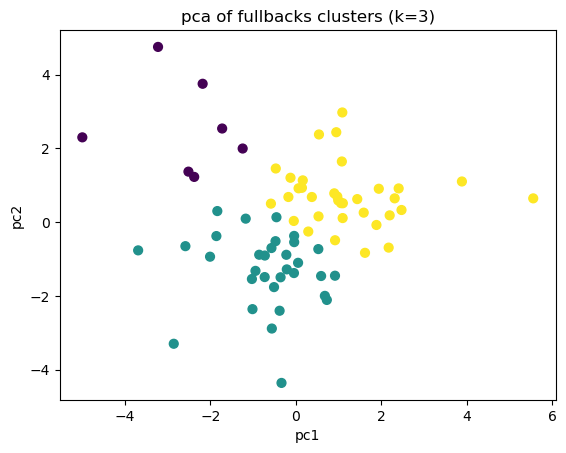

In [134]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

features = [
    'attack_def_ratio',
    'progression_safety_ratio',
    'creation_disruption_ratio',
    'duel_orientation_ratio',
    'risk_reward_ratio',
    'xGI_per_90',
    'pxt_prevented_per_90',
    'avg_forward_distance',
    'ground_duels_won_per_90',
    'interceptions_per_90'
]

X = filtered_df[features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=50)
filtered_df['cluster'] = kmeans.fit_predict(X_scaled)
sil_score = silhouette_score(X_scaled, filtered_df['cluster'])

print("silhouette score (k=3):", round(sil_score, 3))

summary = filtered_df.groupby('cluster')[features].mean().round(2)
print("\ncluster summary:")
display(summary)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=filtered_df['cluster'], cmap='viridis', s=40)
plt.xlabel('pc1')
plt.ylabel('pc2')
plt.title('pca of fullbacks clusters (k=3)')
plt.show()


In [147]:
mapping = {0: 'Attacking/Creative', 1: 'Conservative/Low Involvement', 2:'Traditional/High Defensive Load'}
filtered_df['role_label'] = filtered_df['cluster'].map(mapping)

In [164]:
import requests
from bs4 import BeautifulSoup

def get_transfermarkt_player_data(player_name):
    url = f"https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query={player_name.replace(' ', '+')}"
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    row = soup.select_one("table.items tbody tr")
    if not row:
        return None

    player_link_tag = row.select_one("a[href*='/profil/spieler/']")
    player_name = player_link_tag.text.strip() if player_link_tag else None
    player_url = (
        "https://www.transfermarkt.com" + player_link_tag["href"]
        if player_link_tag else None
    )

    club_tag = row.select_one("td a[title]")
    club_name = club_tag["title"] if club_tag else None

    position = row.select("td.zentriert")[0].text.strip() if len(row.select("td.zentriert")) > 0 else None
    age = row.select("td.zentriert")[2].text.strip() if len(row.select("td.zentriert")) > 2 else None

    value_tag = row.select_one("td.rechts.hauptlink")
    market_value = value_tag.text.strip() if value_tag else None

    return {
        "player_name": player_name,
        "club": club_name,
        "position": position,
        "age": age,
        "market_value": market_value,
        "profile_url": player_url
    }

import time

results = []

for name in filtered_df['playerName']:
    data = get_transfermarkt_player_data(name)
    if data:
        results.append(data)
    else:
        results.append({
            'player_name': name,
            'club': None,
            'position': None,
            'age': None,
            'market_value': None,
            'profile_url': None
        })
    time.sleep(1) 

values_df = pd.DataFrame(results)
values_df

,player_name,club,position,age,market_value,profile_url
0,Joshua Kimmich,Joshua Kimmich,DM,30,€45.00m,https://www.transfermarkt.com/joshua-kimmich/p...
1,Raphaël Guerreiro,Raphaël Guerreiro,LB,31,€8.00m,https://www.transfermarkt.com/raphael-guerreir...
2,Pavel Kaderabek,Pavel Kaderabek,RB,33,€1.70m,https://www.transfermarkt.com/pavel-kaderabek/...
3,Silvan Widmer,Silvan Widmer,RB,32,€1.20m,https://www.transfermarkt.com/silvan-widmer/pr...
4,Yannick Gerhardt,Yannick Gerhardt,CM,31,€2.50m,https://www.transfermarkt.com/yannick-gerhardt...
...,...,...,...,...,...,...
68,Noah Weißhaupt,Noah Weißhaupt,LW,24,€4.00m,https://www.transfermarkt.com/noah-weisshaupt/...
69,Fabio Torsiello,Fabio Torsiello,CF,20,€400k,https://www.transfermarkt.com/fabio-torsiello/...
70,David Jurásek,David Jurásek,LB,25,€5.00m,https://www.transfermarkt.com/david-jurasek/pr...
71,Tim Oermann,Tim Oermann,RB,22,€5.00m,https://www.transfermarkt.com/tim-oermann/prof...


In [176]:
import re

def parse_value(v):
    if not isinstance(v, str):
        return None

    v = v.strip().replace('€', '').replace('Th.', '').replace(',', '.').lower()
    v = re.sub(r'(?<=\d)\.(?=\d{3}\b)', '', v)

    if 'm' in v:
        return float(v.replace('m', '').strip())
    if 'k' in v:
        return float(v.replace('k', '').strip()) / 1_000

    try:
        return float(v)
    except:
        return None

values_df['market_value_million_eur'] = values_df['market_value'].apply(parse_value)

In [194]:
final_with_values = filtered_df.merge(values_df[['player_name','market_value_million_eur']], left_on='playerName',right_on='player_name', how='left')

In [195]:
final_with_values = final_with_values.merge(players[['commonname','leg','preferredPosition','birthdate']],left_on='playerName',right_on='commonname',how='left')

In [196]:
from datetime import date

final_with_values['birthdate'] = pd.to_datetime(final_with_values['birthdate'], errors='coerce')

today = pd.Timestamp(date.today())

final_with_values['Age'] = (
    today.year - final_with_values['birthdate'].dt.year
    - ((today.month < final_with_values['birthdate'].dt.month) |
       ((today.month == final_with_values['birthdate'].dt.month) &
        (today.day < final_with_values['birthdate'].dt.day)))
)


In [202]:
final_with_values.to_excel('phase1_fullbacks.xlsx',index=False)

## Insights

In [243]:
df = pd.read_excel("phase1_fullbacks.xlsx")

In [244]:
rank_cols = [
    'xg_per_90', 'postxg_per_90', 'xthreat_per_90',
    'pass_accuracy', 'dribble_success_rate',
    'pxT_from_passes_and_dribbles_per_90', 'total_bypassed_per_90',
    'execution_ratio', 'avg_forward_distance', 'prog_passes_per_90',
    'successful_prog_passes_per_90', 'carries_into_final_third_per_90',
    'ball_losses_per_90', 'critical_losses_per_90',
    'ground_duels_won_per_90', 'interceptions_per_90', 'pxt_prevented_per_90',
    'ball_recoveries_per_90', 'cross_accuracy', 'pxt_from_crosses',
    'carry_vs_pass_progress_ratio', 'pxt_per_progressive_action',
    'cross_value', 'risk_index', 'safety_index', 'goal_involvement_per_90',
    'xGI_per_90', 'attack_to_defense_ratio', 'cross_to_pass_ratio',
    'market_value_million_eur'
]

for col in rank_cols:
    df[f'{col}_rank_global'] = (
        df[col].rank(ascending=False, method='min')
        .fillna(np.nan)
    )
    df[f'{col}_rank_role'] = (
        df.groupby('role_label')[col]
          .rank(ascending=False, method='min')
          .fillna(np.nan)
    )

In [245]:
from sklearn.preprocessing import MinMaxScaler

df['inv_ball_losses_per_90'] = -df['ball_losses_per_90']
df['inv_critical_losses_per_90'] = -df['critical_losses_per_90']

themes = {
    'passing': ['pass_accuracy', 'cross_accuracy', 'successful_prog_passes_per_90'],
    'progressiveness': ['prog_passes_per_90', 'carry_vs_pass_progress_ratio', 'pxt_per_progressive_action', 'avg_forward_distance', 'carries_into_final_third_per_90'],
    'defending': ['ground_duels_won_per_90', 'interceptions_per_90', 'pxt_prevented_per_90', 'ball_recoveries_per_90'],
    'chance_creation': ['xGI_per_90', 'cross_value', 'pxt_from_crosses', 'goal_involvement_per_90'],
    'security': ['inv_ball_losses_per_90', 'inv_critical_losses_per_90', 'safety_index']
}



scaler = MinMaxScaler()

for theme, cols in themes.items():
    pct_cols = [f'{c}_pct' for c in cols]
    df[pct_cols] = scaler.fit_transform(df[cols].fillna(0))
    df[f'{theme}_theme_index'] = df[pct_cols].mean(axis=1)
    df.drop(columns=pct_cols, inplace=True)

In [48]:
#df.to_excel('fullbacks_final_for_pivot.xlsx',index=False)

## Recommendation Analysis

1. What does a 3-4-1-2 wing-back need?

In a 3-4-1-2, the wing-backs are a key position:

They provide width and progression in possession.

They have to recover and form a back 5 out of possession.

They often provide crosses and cutbacks as main chance creation. 

So, conceptually, you want:

High engine / involvement (touches, events, minutes)

Progression (carries + progressive passes)

Chance creation (xGI, cross quality, pxT from wide areas)

Defensive work (duels, interceptions, recoveries, disrupting pxT)

Security (low high-value ball losses in bad zones)

Championship is physical, transitional, lots of duels and crossing.

Baseline Filters:

 - Played enough minutes
 - Is usually involved
 - Age, not too old to give years and potential resale

In [246]:
df['market_value_million_eur'] = df['market_value_million_eur'].fillna(df['market_value_million_eur'].mean())
df['market_value_norm'] = (
    df['market_value_million_eur'].max() - df['market_value_million_eur']
) / (df['market_value_million_eur'].max() - df['market_value_million_eur'].min())



After shortlisting, we can then have two layers of evaluation:

 - Specific Role Fit
 - Overall Quality

Role Fit
 - measure how well the player performs within his role archetype
 - this can tell us how good the player is at doing what his archtype is supposed to do

so we make qualitiative weighting for the generated theme indexes specific for each archtype

In [247]:
df['leg']

0     RIGHT
1      LEFT
2     RIGHT
3     RIGHT
4      LEFT
      ...  
68    RIGHT
69    RIGHT
70     LEFT
71    RIGHT
72     LEFT
Name: leg, Length: 73, dtype: object

In [248]:
def Recommender(df,role,role_weights):

    #Shortlist first
    
    shortlisted_players = df[(df['Age'] < 30) & (df['role_label']!='Conservative/Low Involvement')]
    shortlisted_players_kpis = shortlisted_players[['playerName',
                                                    'role_label',
                                                    'Age',
                                                    'preferredPosition',
                                                    'leg',
                                                    'market_value_million_eur',
                                                    'market_value_norm',
                                                    'minutes_played',
                                                    'passing_theme_index',
                                                    'progressiveness_theme_index',
                                                    'defending_theme_index',
                                                    'chance_creation_theme_index',
                                                    'security_theme_index'
                                                   ]]
    role_specific = shortlisted_players_kpis[shortlisted_players_kpis['role_label'] == role].copy()

    theme_cols = [
        'passing_theme_index',
        'progressiveness_theme_index',
        'defending_theme_index',
        'chance_creation_theme_index',
        'security_theme_index'
    ]
    
    for col in theme_cols:
        role_specific[col + '_norm'] = (
            role_specific[col] - role_specific[col].min()
        ) / (role_specific[col].max() - role_specific[col].min())


    # rolefit using dynamic weights
    role_specific['RoleFit'] = 0
    for col, w in role_weights.items():
        role_specific['RoleFit'] += w * role_specific[col + '_norm']

    #get overall quality
    theme_cols = [
        'passing_theme_index',
        'progressiveness_theme_index',
        'defending_theme_index',
        'chance_creation_theme_index',
        'security_theme_index'
    ]
    
    df_quality = df.copy()
    
    for col in theme_cols:
        df_quality[col + '_global_norm'] = (
            df_quality[col] - df_quality[col].min()
        ) / (df_quality[col].max() - df_quality[col].min())
    
    
    df_quality['Quality'] = (
        df_quality[['passing_theme_index_global_norm',
                    'progressiveness_theme_index_global_norm',
                    'defending_theme_index_global_norm',
                    'chance_creation_theme_index_global_norm',
                    'security_theme_index_global_norm']]
        .mean(axis=1)
    )
    
    df_quality['Quality_adjusted'] =  df_quality['Quality'] * np.minimum(1, df_quality['minutes_played'] / 3060)


    role_specific = role_specific.merge(
        df_quality[['playerName', 'Quality','Quality_adjusted']],
        on='playerName',
        how='left'
    )
    
    role_specific['BlackburnScore'] = (
        0.5 * role_specific['RoleFit'] +
        0.5 * role_specific['Quality_adjusted']
    )
    
    role_specific['ValueForMoney'] = (
        0.7 * role_specific['BlackburnScore'] +
        0.3 * role_specific['market_value_norm']
    )

    return role_specific.sort_values('ValueForMoney',ascending=False)

In [249]:
attacking_weights = {
    'chance_creation_theme_index': 0.30,
    'progressiveness_theme_index': 0.25,
    'passing_theme_index': 0.20,
    'defending_theme_index': 0.15,
    'security_theme_index': 0.10
}

att_shortlist = Recommender(df,'Attacking/Creative',attacking_weights)

In [250]:
defensive_weights = {
    'defending_theme_index': 0.30,
    'security_theme_index': 0.25,
    'progressiveness_theme_index': 0.20,
    'passing_theme_index': 0.15,
    'chance_creation_theme_index': 0.10
}

def_shortlist = Recommender(df,'Traditional/High Defensive Load',defensive_weights)

In [251]:
with pd.ExcelWriter("Shortlist.xlsx", engine="openpyxl") as writer:
    att_shortlist.to_excel(writer, sheet_name="Attacking_Creative", index=False)
    def_shortlist.to_excel(writer, sheet_name="Traditional_Defensive", index=False)